In [5]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [6]:
# Load Dataset

df = pd.read_csv(r"C:\Users\Admin\Downloads\supermarket_data.csv\supermarket_data.csv")

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/10 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/10 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/10 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/10 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/10 08:26,3.39,17850.0,United Kingdom


In [7]:
# Display Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [8]:
# Check Missing Values

df.isnull().sum()

Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

In [9]:
# Remove Missing Values

df = df.dropna()

print(df.shape)

(406830, 8)


In [10]:
# Remove Duplicate Records

df = df.drop_duplicates()

print(df.shape)

(401605, 8)


In [11]:
# Convert InvoiceDate into Datetime

df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    format="%d/%m/%y %H:%M"
)

In [12]:
# Create Revenue Feature

df["Revenue"] = df["Quantity"] * df["Price"]

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [13]:
# Extract Date Features

df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day
df["Hour"] = df["InvoiceDate"].dt.hour

In [14]:
# Encode StockCode

stock_encoder = LabelEncoder()

df["StockCode"] = stock_encoder.fit_transform(df["StockCode"])

In [15]:
# Encode Country

country_encoder = LabelEncoder()

df["Country"] = country_encoder.fit_transform(df["Country"])

In [16]:
# Define Features and Target

X = df[["StockCode", "Price", "Country", "Month", "Day", "Hour"]]

y = df["Quantity"]

In [17]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
# Create Random Forest Model

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [20]:
# Train AI Model

model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [21]:
# Predict Quantity

y_pred = model.predict(X_test)

In [22]:
# Evaluate Model

print("R2 Score :", r2_score(y_test, y_pred))
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE :", mean_squared_error(y_test, y_pred)**0.5)

R2 Score : -1.6994255650661279
MAE : 9.535878374374027
RMSE : 474.17455537927


In [23]:
# Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

importance

,Feature,Importance
0,StockCode,0.549310
1,Price,0.333569
4,Day,0.063344
3,Month,0.027038
5,Hour,0.021746
2,Country,0.004994


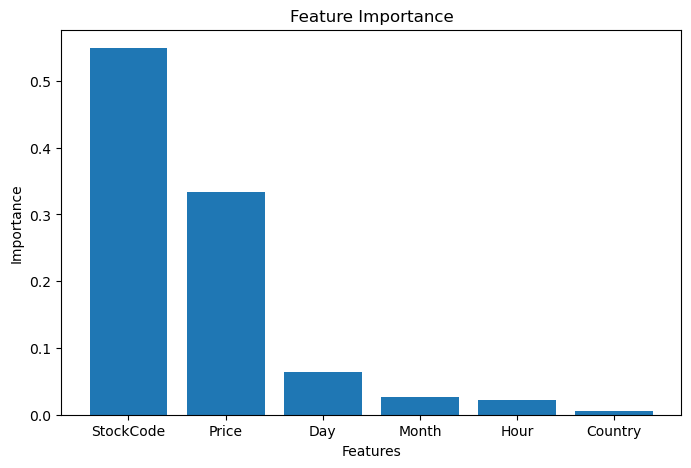

In [21]:
# Plot Feature Importance

plt.figure(figsize=(8,5))
plt.bar(importance["Feature"], importance["Importance"])
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [24]:
# Save Trained AI Model

joblib.dump(model, "MarketMind_RF_Model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [25]:
# Load Saved AI Model

loaded_model = joblib.load("MarketMind_RF_Model.pkl")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [26]:
# Test Loaded Model

loaded_model.predict(X_test.head())

array([ 1.94      ,  8.07      ,  2.01083333, 11.        ,  1.        ])

In [27]:
# Save Cleaned Dataset

df.to_csv("cleaned_supermarket_data.csv", index=False)

print("Cleaned Dataset Saved Successfully!")

Cleaned Dataset Saved Successfully!


In [28]:
# Display Final Dataset Shape

print(df.shape)

(401605, 13)


In [30]:
# Project Completion Message

print("MarketMind AI Model Completed Successfully!")

MarketMind AI Model Completed Successfully!


In [31]:
# Load Saved AI Model

import joblib

model = joblib.load("MarketMind_RF_Model.pkl")

print("Model Loaded Successfully!")

Model Loaded Successfully!


In [32]:
print(type(model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [33]:
# Test Prediction

sample = X_test.head(5)

prediction = model.predict(sample)

print(prediction)

[ 1.94        8.07        2.01083333 11.          1.        ]
